In [1]:
# Cell 1: Setup

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
import math

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    tf.config.experimental.set_memory_growth(gpus[0], True)
    tf.config.optimizer.set_jit(True)

keras.mixed_precision.set_global_policy('mixed_float16')

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")
print(f"Compute dtype: {keras.mixed_precision.global_policy().compute_dtype}")

np.random.seed(42)
tf.random.set_seed(42)

LATENT_DIM    = 16
KL_WEIGHT     = 0.1
BATCH_SIZE    = 256
LEARNING_RATE = 0.003
WEIGHT_DECAY  = 0.0005
CLIPNORM      = 2.0
EPOCHS        = 100
STAGE_EPOCHS  = int(EPOCHS * 0.3)

LR_DECAY_FACTOR   = EPOCHS * 0.015
AES_SENSITIVITY   = 0.05
AES_START_EPOCH   = int(STAGE_EPOCHS * 0.3)
MODEL_START_EPOCH = int(STAGE_EPOCHS * 0.35)
WARMUP_EPOCHS     = int(STAGE_EPOCHS * 0.05)

BASE_FILTERS   = 16
MAX_LAYERS     = 4
BOTTLENECK_DIM = 4

IMAGE_SIZE_X = 32
IMAGE_SIZE_Y = 32
CHANNELS     = 3
STRIDE       = 2

2026-04-25 01:20:39.418405: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-25 01:20:40.035268: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-25 01:20:42.562953: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow version: 2.20.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Compute dtype: float16


In [2]:
# Cell 2: Architecture

class Sampling(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        epsilon = keras.random.normal(shape=keras.ops.shape(z_mean), dtype=z_mean.dtype)
        return z_mean + keras.ops.exp(0.5 * z_log_var) * epsilon


def build_encoder(num_layers, latent_dim=LATENT_DIM):
    inputs = keras.Input(shape=(IMAGE_SIZE_X, IMAGE_SIZE_Y, CHANNELS))
    x = inputs

    max_down = int(math.log2(IMAGE_SIZE_X // BOTTLENECK_DIM))
    num_down = min(num_layers, max_down)

    for i in range(num_layers):
        filters = BASE_FILTERS * (2 ** i)
        stride  = STRIDE if i < num_down else 1

        # NxN conv to extract features and downsample
        x = layers.Conv2D(filters, 3, strides=stride, padding='same',
                          use_bias=False, name=f'enc_conv_{i}')(x)
        x = layers.BatchNormalization(name=f'enc_bn_{i}')(x)
        x = layers.Activation('relu', name=f'enc_relu_{i}')(x)
        # 1x1 conv for channel mixing (as supervisor specified)
        x = layers.Conv2D(filters, 1, padding='same',
                          use_bias=False, name=f'enc_1x1_{i}')(x)
        x = layers.BatchNormalization(name=f'enc_bn1x1_{i}')(x)
        x = layers.Activation('relu', name=f'enc_relu1x1_{i}')(x)

    # Bottleneck: 1x1 convs produce z_mean and z_log_var as spatial maps
    # dtype='float32' keeps these in full precision under mixed precision
    z_mean    = layers.Conv2D(latent_dim, 1, name='z_mean',    dtype='float32')(x)
    z_log_var = layers.Conv2D(latent_dim, 1, name='z_log_var', dtype='float32')(x)
    z         = Sampling()([z_mean, z_log_var])

    return keras.Model(inputs, [z_mean, z_log_var, z], name=f'encoder_L{num_layers}')


def build_decoder(num_layers, latent_dim=LATENT_DIM):
    max_down = int(math.log2(IMAGE_SIZE_X // BOTTLENECK_DIM))
    num_down = min(num_layers, max_down)
    current_size = IMAGE_SIZE_X // (2 ** num_down)

    inputs = keras.Input(shape=(current_size, current_size, latent_dim))
    x = inputs

    for i in range(num_layers - 1, -1, -1):
        filters = BASE_FILTERS * (2 ** i)
        stride  = STRIDE if i < num_down else 1

        # 1x1 conv to mix channels before upsampling (mirror of encoder)
        x = layers.Conv2D(filters, 1, padding='same',
                          use_bias=False, name=f'dec_1x1_{i}')(x)
        x = layers.BatchNormalization(name=f'dec_bn1x1_{i}')(x)
        x = layers.Activation('relu', name=f'dec_relu1x1_{i}')(x)
        # NxN transpose conv to upsample
        x = layers.Conv2DTranspose(filters, 3, strides=stride, padding='same',
                                   use_bias=False, name=f'dec_convT_{i}')(x)
        x = layers.BatchNormalization(name=f'dec_bn_{i}')(x)
        x = layers.Activation('relu', name=f'dec_relu_{i}')(x)

    outputs = layers.Conv2D(CHANNELS, 3, padding='same', activation='tanh',
                            dtype='float32', name='dec_output')(x)

    return keras.Model(inputs, outputs, name=f'decoder_L{num_layers}')


def freeze_outer_blocks(encoder, decoder, n_frozen_blocks):
    """
    Freeze the n_frozen_blocks outermost encoder and decoder blocks.
    These are the blocks from the previous training stage.
    Targets layers by name so it's precise regardless of model size.
    """
    enc_prefixes = ['enc_conv', 'enc_bn', 'enc_relu', 'enc_1x1', 'enc_bn1x1', 'enc_relu1x1']
    dec_prefixes = ['dec_1x1', 'dec_bn1x1', 'dec_relu1x1', 'dec_convT', 'dec_bn', 'dec_relu']

    for i in range(n_frozen_blocks):
        for prefix in enc_prefixes:
            try:
                encoder.get_layer(f'{prefix}_{i}').trainable = False
            except ValueError:
                pass
        for prefix in dec_prefixes:
            try:
                decoder.get_layer(f'{prefix}_{i}').trainable = False
            except ValueError:
                pass

    n_enc_frozen = sum(1 for l in encoder.layers if not l.trainable)
    n_dec_frozen = sum(1 for l in decoder.layers if not l.trainable)
    print(f'  Frozen {n_enc_frozen} encoder layers, {n_dec_frozen} decoder layers')


def transfer_weights(old_model, new_model):
    """Copy weights from old model to new model by matching layer names."""
    transferred = 0
    for new_layer in new_model.layers:
        try:
            old_layer = old_model.get_layer(new_layer.name)
            new_layer.set_weights(old_layer.get_weights())
            transferred += 1
        except (ValueError, AttributeError):
            continue
    print(f'  Transferred weights for {transferred} layers')


class VAE(keras.Model):
    def __init__(self, encoder, decoder, kl_weight_var, **kwargs):
        super().__init__(**kwargs)
        self.encoder       = encoder
        self.decoder       = decoder
        self.kl_weight_var = tf.Variable(kl_weight_var, trainable=False, dtype=tf.float32)

        self._loss_tracker       = keras.metrics.Mean(name='loss')
        self._recon_loss_tracker = keras.metrics.Mean(name='recon_loss')
        self._kl_loss_tracker    = keras.metrics.Mean(name='kl_loss')

    @property
    def metrics(self):
        return [self._loss_tracker, self._recon_loss_tracker, self._kl_loss_tracker]

    def call(self, x):
        z_mean, z_log_var, z = self.encoder(x)
        return self.decoder(z)

    def _compute_losses(self, x, reconstruction, z_mean, z_log_var):
        x              = tf.cast(x,              tf.float32)
        reconstruction = tf.cast(reconstruction, tf.float32)
        z_mean         = tf.cast(z_mean,         tf.float32)
        z_log_var      = tf.cast(z_log_var,      tf.float32)
        recon_loss = tf.reduce_mean(
            tf.reduce_sum(tf.square(x - reconstruction), axis=[1, 2, 3])
        )
        spatial_size = tf.cast(tf.shape(z_mean)[1] * tf.shape(z_mean)[2], tf.float32)
        kl_loss = -0.5 * tf.reduce_mean(
            tf.reduce_sum(1.0 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=[1, 2, 3])
        ) / spatial_size
        total_loss = recon_loss + tf.cast(self.kl_weight_var, tf.float32) * kl_loss
        return total_loss, recon_loss, kl_loss

    def _update_metrics(self, total, recon, kl):
        self._loss_tracker.update_state(total)
        self._recon_loss_tracker.update_state(recon)
        self._kl_loss_tracker.update_state(kl)
        return {
            'loss':       self._loss_tracker.result(),
            'recon_loss': self._recon_loss_tracker.result(),
            'kl_loss':    self._kl_loss_tracker.result(),
        }

    def train_step(self, data):
        x, _ = data
        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(x, training=True)
            reconstruction       = self.decoder(z, training=True)
            total, recon, kl     = self._compute_losses(x, reconstruction, z_mean, z_log_var)
        grads = tape.gradient(total, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        return self._update_metrics(total, recon, kl)

    def test_step(self, data):
        x, _ = data
        z_mean, z_log_var, z = self.encoder(x, training=False)
        reconstruction       = self.decoder(z, training=False)
        total, recon, kl     = self._compute_losses(x, reconstruction, z_mean, z_log_var)
        return self._update_metrics(total, recon, kl)


encoder = build_encoder(num_layers=MAX_LAYERS, latent_dim=LATENT_DIM)
decoder = build_decoder(num_layers=MAX_LAYERS, latent_dim=LATENT_DIM)
vae     = VAE(encoder, decoder, kl_weight_var=KL_WEIGHT, name='vae')
print('VAE built.')

I0000 00:00:1777076444.597470 1021879 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5560 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


VAE built.


In [ ]:
# Cell 3: Custom Callbacks

class KLAnneal(keras.callbacks.Callback):
 
    #Sigmoid KL annealing: smoothly increases KL weight from near-0 to weight_target over warmup_epochs. Restarts automatically each stage
    def __init__(self, weight_target=KL_WEIGHT, warmup_epochs=STAGE_EPOCHS,
                 steepness=0.2, verbose=True):
        super().__init__()
        self.kl_weight_target = weight_target
        self.warmup_epochs    = warmup_epochs
        self.steepness        = steepness
        self.verbose          = verbose

    def on_epoch_begin(self, epoch, logs=None):
        midpoint   = self.warmup_epochs / 2
        progress   = (epoch - midpoint) / (self.steepness * self.warmup_epochs)
        new_weight = self.kl_weight_target / (1.0 + math.exp(-progress))
        self.model.kl_weight_var.assign(new_weight)
        if self.verbose and epoch < self.warmup_epochs:
            print(f'\n[KL Annealing] Epoch {epoch + 1}: KL weight = {new_weight:.4f}')


class DelayedModelCheckpoint(keras.callbacks.ModelCheckpoint):
    #ModelCheckpoint that only starts saving after start_epoch
    def __init__(self, *args, start_epoch=0, **kwargs):
        super().__init__(*args, **kwargs)
        self.start_epoch = start_epoch

    def on_epoch_end(self, epoch, logs=None):
        if epoch < self.start_epoch:
            return
        super().on_epoch_end(epoch, logs)


class AdaptiveEarlyStopping(keras.callbacks.Callback):
    #Early stopping whose patience shrinks after meaningful LR reductions
    def __init__(self, monitor='val_loss', base_patience=7, min_delta=0.1,
                 patience_decay=0.7, min_patience=3, start_epoch=0,
                 restore_best_weights=True, verbose=True):
        super().__init__()
        self.monitor              = monitor
        self.base_patience        = base_patience
        self.current_patience     = base_patience
        self.min_delta            = min_delta
        self.patience_decay       = patience_decay
        self.min_patience         = min_patience
        self.start_epoch          = start_epoch
        self.restore_best_weights = restore_best_weights
        self.verbose              = verbose
        self.best                 = np.inf
        self.wait                 = 0
        self.best_weights         = None
        self._prev_lr             = None

    def on_train_begin(self, logs=None):
        self.best             = np.inf
        self.wait             = 0
        self.best_weights     = None
        self.current_patience = self.base_patience
        self._prev_lr         = float(keras.backend.get_value(self.model.optimizer.learning_rate))

    def on_epoch_end(self, epoch, logs=None):
        if epoch < self.start_epoch:
            return
        logs    = logs or {}
        current = logs.get(self.monitor)
        if current is None:
            return
        current_lr = float(keras.backend.get_value(self.model.optimizer.learning_rate))
        if self._prev_lr is not None:
            relative_drop = (self._prev_lr - current_lr) / (self._prev_lr + 1e-10)
            if relative_drop > AES_SENSITIVITY:
                self.current_patience = max(
                    self.min_patience,
                    int(self.current_patience * self.patience_decay)
                )
                if self.verbose:
                    print(f'\n[AdaptiveES] LR dropped {self._prev_lr:.2e} -> {current_lr:.2e}; patience -> {self.current_patience}')
        self._prev_lr = current_lr
        if current < self.best - self.min_delta:
            self.best         = current
            self.wait         = 0
            self.best_weights = self.model.get_weights()
        else:
            self.wait += 1
            if self.verbose:
                print(f'\n[AdaptiveES] No improvement for {self.wait}/{self.current_patience} epochs (best={self.best:.4f})')
            if self.wait >= self.current_patience:
                self.model.stop_training = True
                if self.restore_best_weights and self.best_weights is not None:
                    if self.verbose:
                        print('\n[AdaptiveES] Restoring best weights.')
                    self.model.set_weights(self.best_weights)

In [ ]:
# Cell 4: Data Pipeline & Training

(x_train, _), (x_test, _) = keras.datasets.cifar10.load_data()

x_train = (x_train.astype('float32') / 127.5) - 1.0
x_test  = (x_test.astype('float32')  / 127.5) - 1.0

print(f'Training data: {x_train.shape}')
print(f'Test data:     {x_test.shape}')


@tf.function
def augment(x, y):
    x = tf.image.random_flip_left_right(x)
    x = tf.image.random_brightness(x, max_delta=0.1)
    x = tf.image.random_contrast(x, lower=0.9, upper=1.1)
    x = tf.clip_by_value(x, -1.0, 1.0)
    return x, x


train_dataset = (
    tf.data.Dataset.from_tensor_slices((x_train, x_train))
    .shuffle(len(x_train))
    .map(augment, num_parallel_calls=tf.data.AUTOTUNE)
    .cache()
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

val_dataset = (
    tf.data.Dataset.from_tensor_slices((x_test, x_test))
    .cache()
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

steps_per_epoch = len(x_train) // BATCH_SIZE
total_steps     = steps_per_epoch * STAGE_EPOCHS
warmup_steps    = steps_per_epoch * WARMUP_EPOCHS

def lr_schedule():
    """Fresh schedule each stage so LR starts from the beginning of the warmup curve."""
    return keras.optimizers.schedules.CosineDecay(
        initial_learning_rate=LEARNING_RATE / 10,
        decay_steps=total_steps * 3,
        alpha=1e-6,
        warmup_target=LEARNING_RATE,
        warmup_steps=warmup_steps,
    )

kl_anneal  = KLAnneal(weight_target=KL_WEIGHT, warmup_epochs=STAGE_EPOCHS, verbose=True)

early_stop = AdaptiveEarlyStopping(
    monitor='val_loss',
    base_patience=7,
    min_delta=0.5,
    start_epoch=AES_START_EPOCH,
    verbose=True
)

csv_logger = keras.callbacks.CSVLogger('training_log.csv', append=True)

histories        = []
previous_encoder = None
previous_decoder = None

for stage_layers in range(1, MAX_LAYERS + 1):

    print(f'\n{"="*50}')
    print(f'Training Stage: {stage_layers} / {MAX_LAYERS}')
    print(f'{"="*50}\n')

    encoder = build_encoder(stage_layers)
    decoder = build_decoder(stage_layers)

    if previous_encoder is not None:
        print('Transferring weights from previous stage...')
        transfer_weights(previous_encoder, encoder)
        transfer_weights(previous_decoder, decoder)
        print(f'Freezing {stage_layers - 1} outer block(s)...')
        freeze_outer_blocks(encoder, decoder, n_frozen_blocks=stage_layers - 1)

    vae = VAE(encoder, decoder, kl_weight_var=KL_WEIGHT)

    # Fresh LR schedule + optimizer each stage
    lr_optimizer = keras.optimizers.AdamW(
        learning_rate=lr_schedule(),
        weight_decay=WEIGHT_DECAY,
        clipnorm=CLIPNORM,
    )
    vae.compile(optimizer=lr_optimizer)

    # Build model before fit so checkpoint callback works correctly
    vae(tf.zeros((1, IMAGE_SIZE_X, IMAGE_SIZE_Y, CHANNELS)))

    checkpoint = DelayedModelCheckpoint(
        f'vae_stage{stage_layers}_best.weights.h5',
        start_epoch=MODEL_START_EPOCH,
        monitor='val_loss',
        save_best_only=True,
        save_weights_only=True,
        verbose=1,
    )

    # Lambda uses vae from outer scope -- in Python closures capture the
    # variable name not the value, so this always reads the current vae
    print_lr = keras.callbacks.LambdaCallback(
        on_epoch_begin=lambda epoch, logs: print(f'\n[LR: {float(vae.optimizer.learning_rate):.2e}]')
    )

    print('Starting training.')
    history = vae.fit(
        train_dataset,
        validation_data=val_dataset,
        epochs=STAGE_EPOCHS,
        verbose=2,
        callbacks=[print_lr, kl_anneal, early_stop, checkpoint, csv_logger]
    )

    previous_encoder = encoder
    previous_decoder = decoder
    histories.append(history.history)

/home/username/tf-env/lib/python3.12/site-packages/keras/src/datasets/cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


Training data: (50000, 32, 32, 3)
Test data:     (10000, 32, 32, 3)

Training Stage: 1 / 4



2026-04-25 01:20:52.736857: E tensorflow/core/util/util.cc:131] oneDNN supports DT_HALF only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.
2026-04-25 01:20:52.796388: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91900


Starting training.

[LR: 3.00e-04]

[KL Annealing] Epoch 1: KL weight = 0.0076
Epoch 1/30


2026-04-25 01:20:58.240573: I external/local_xla/xla/service/service.cc:163] XLA service 0x73416c006310 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-04-25 01:20:58.240614: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 4060 Laptop GPU, Compute Capability 8.9
I0000 00:00:1777076458.307955 1021966 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
2026-04-25 01:20:59.931194: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.


196/196 - 21s - 109ms/step - kl_loss: 14.0670 - loss: 368.6215 - recon_loss: 368.5148 - val_kl_loss: 13.1847 - val_loss: 88.6137 - val_recon_loss: 88.5137

[LR: 3.00e-03]

[KL Annealing] Epoch 2: KL weight = 0.0088
Epoch 2/30
196/196 - 2s - 9ms/step - kl_loss: 30.7262 - loss: 47.5647 - recon_loss: 47.2931 - val_kl_loss: 30.9728 - val_loss: 35.0692 - val_recon_loss: 34.7954

[LR: 3.00e-03]

[KL Annealing] Epoch 3: KL weight = 0.0103
Epoch 3/30
196/196 - 2s - 9ms/step - kl_loss: 41.1509 - loss: 27.6110 - recon_loss: 27.1881 - val_kl_loss: 42.6364 - val_loss: 23.3817 - val_recon_loss: 22.9435

[LR: 3.00e-03]

[KL Annealing] Epoch 4: KL weight = 0.0119
Epoch 4/30
196/196 - 2s - 9ms/step - kl_loss: 46.4122 - loss: 21.4134 - recon_loss: 20.8602 - val_kl_loss: 48.2396 - val_loss: 18.2086 - val_recon_loss: 17.6335

[LR: 2.99e-03]

[KL Annealing] Epoch 5: KL weight = 0.0138
Epoch 5/30
196/196 - 2s - 9ms/step - kl_loss: 49.7346 - loss: 17.2352 - recon_loss: 16.5496 - val_kl_loss: 51.8618 - val_l

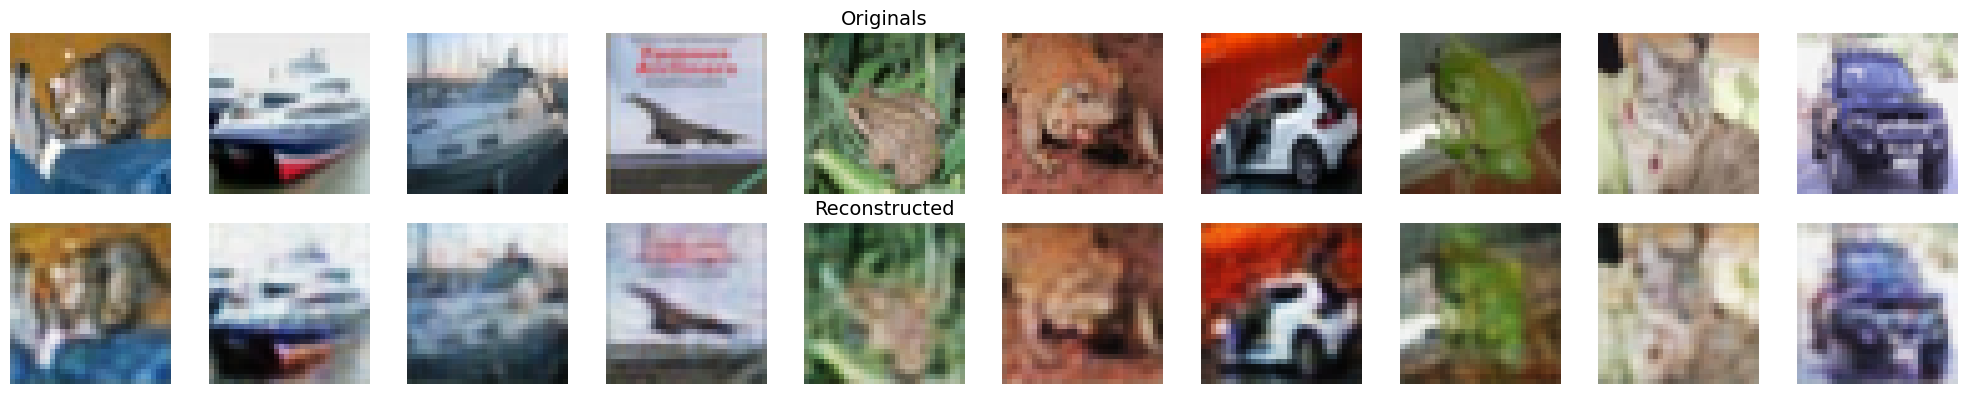

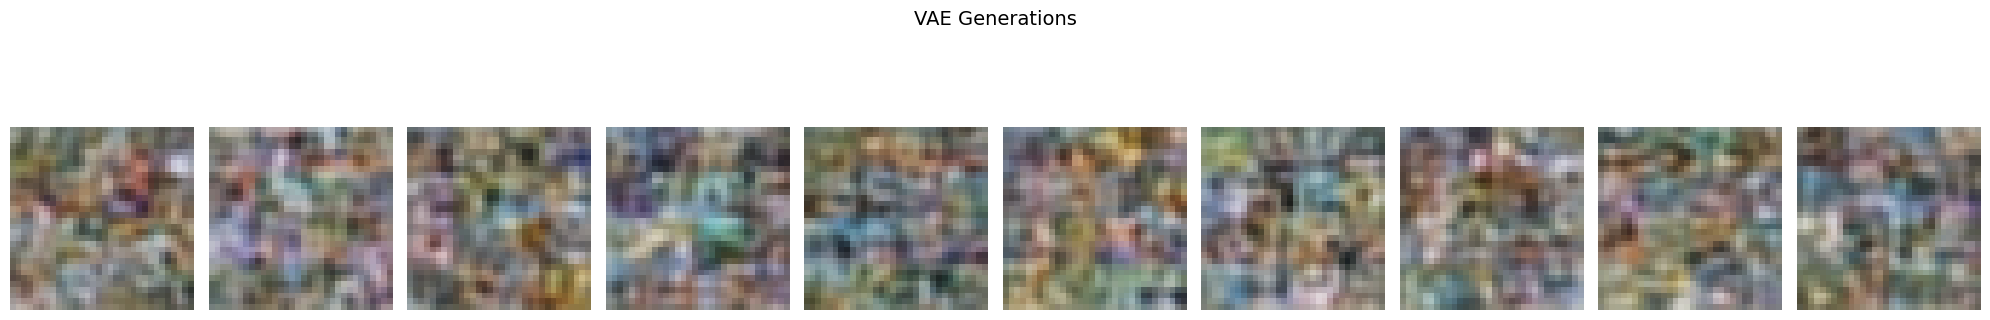

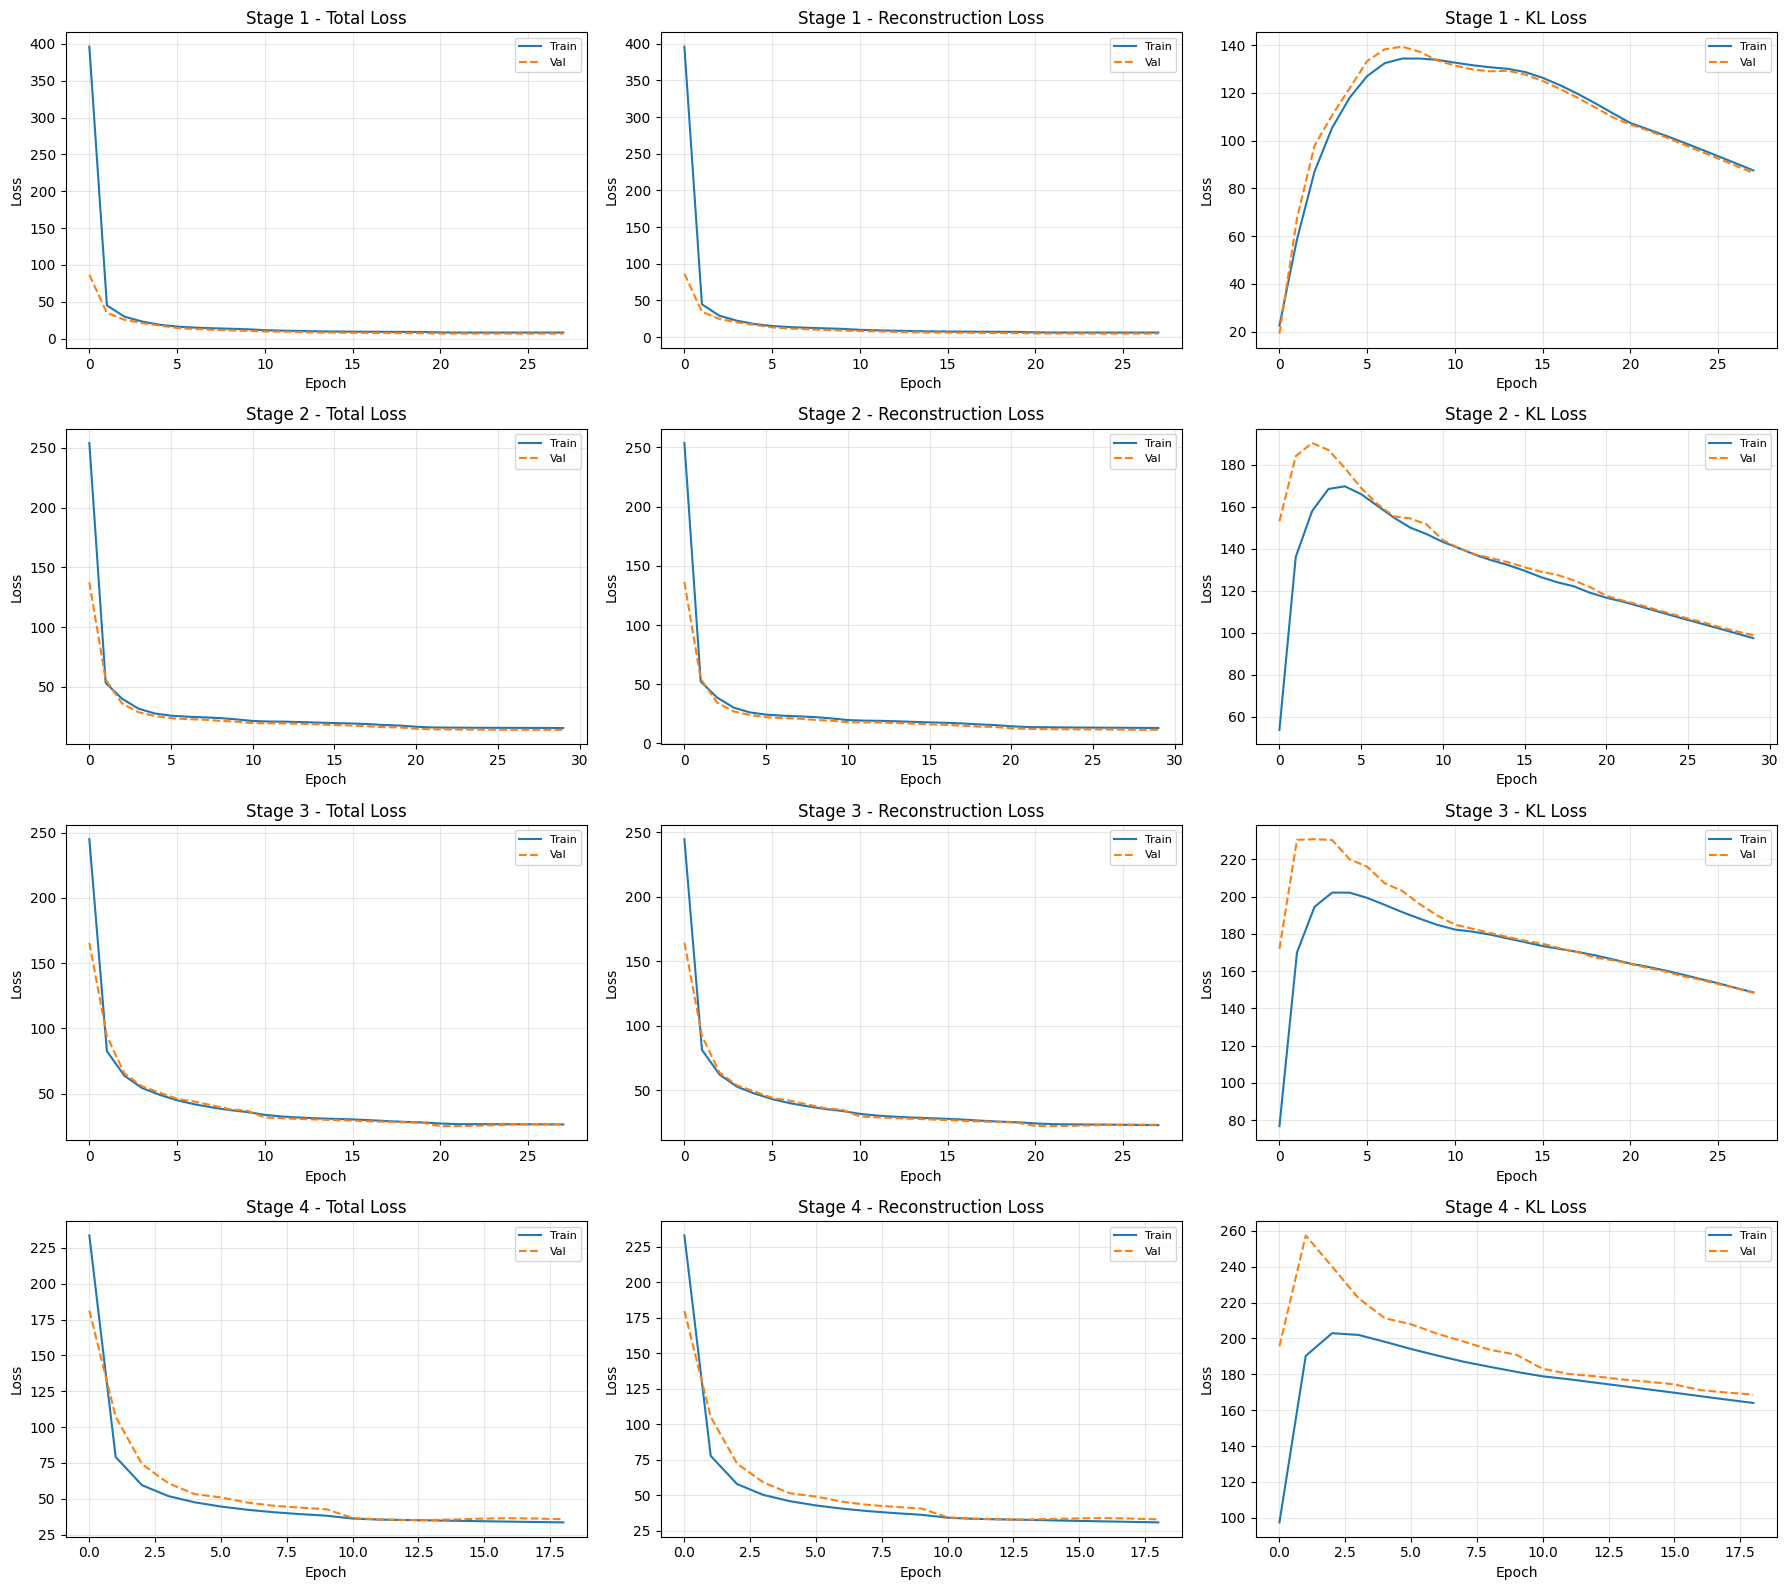


Final stage metrics:
  Stage 1: total=8.23, recon=6.13, kl=87.54
  Stage 2: total=15.53, recon=13.01, kl=97.35
  Stage 3: total=26.40, recon=22.82, kl=148.58
  Stage 4: total=33.58, recon=30.83, kl=164.03


In [ ]:
# Cell 5: Visualisation

def tanh_display(img):
    """Convert tanh outputs [-1, 1] back to [0, 1] for display."""
    return (np.clip(img, -1, 1) + 1) / 2


# Reconstructions
test_samples          = x_test[:10]
z_mean, z_log_var, z  = vae.encoder.predict(test_samples, verbose=0)
reconstructed         = vae.decoder.predict(z, verbose=0)
fig, axes             = plt.subplots(2, 10, figsize=(20, 4))
for i in range(10):
    axes[0, i].imshow(tanh_display(test_samples[i]))
    axes[0, i].axis('off')
    axes[1, i].imshow(tanh_display(reconstructed[i]))
    axes[1, i].axis('off')
axes[0, 4].set_title('Originals',     loc='center', fontsize=14)
axes[1, 4].set_title('Reconstructed', loc='center', fontsize=14)
plt.tight_layout()
plt.show()


# Generations from random latent samples
z_samples = np.random.normal(size=(10, BOTTLENECK_DIM, BOTTLENECK_DIM, LATENT_DIM))
generated = vae.decoder.predict(z_samples, verbose=0)
fig, axes = plt.subplots(1, 10, figsize=(20, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(tanh_display(generated[i]))
    ax.axis('off')
plt.suptitle('VAE Generations', fontsize=14)
plt.tight_layout()
plt.show()


# Loss curves per stage
n_stages  = len(histories)
fig, axes = plt.subplots(n_stages, 3, figsize=(18, 4 * n_stages))
panels    = [
    ('Total Loss',          'loss',       'val_loss'),
    ('Reconstruction Loss', 'recon_loss', 'val_recon_loss'),
    ('KL Loss',             'kl_loss',    'val_kl_loss'),
]
for stage_idx, hist in enumerate(histories):
    for col_idx, (title, train_key, val_key) in enumerate(panels):
        ax = axes[stage_idx, col_idx] if n_stages > 1 else axes[col_idx]
        ax.set_title(f'Stage {stage_idx + 1} - {title}')
        if train_key in hist: ax.plot(hist[train_key], label='Train')
        if val_key   in hist: ax.plot(hist[val_key],   linestyle='--', label='Val')
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Loss')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# Final metrics summary
print('\nFinal stage metrics:')
for i, hist in enumerate(histories):
    print(f'  Stage {i+1}: total={hist["loss"][-1]:.2f}, recon={hist["recon_loss"][-1]:.2f}, kl={hist["kl_loss"][-1]:.2f}')

2026-04-25 01:16:11.077611: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'input_transpose_fusion', 8 bytes spill stores, 4 bytes spill loads



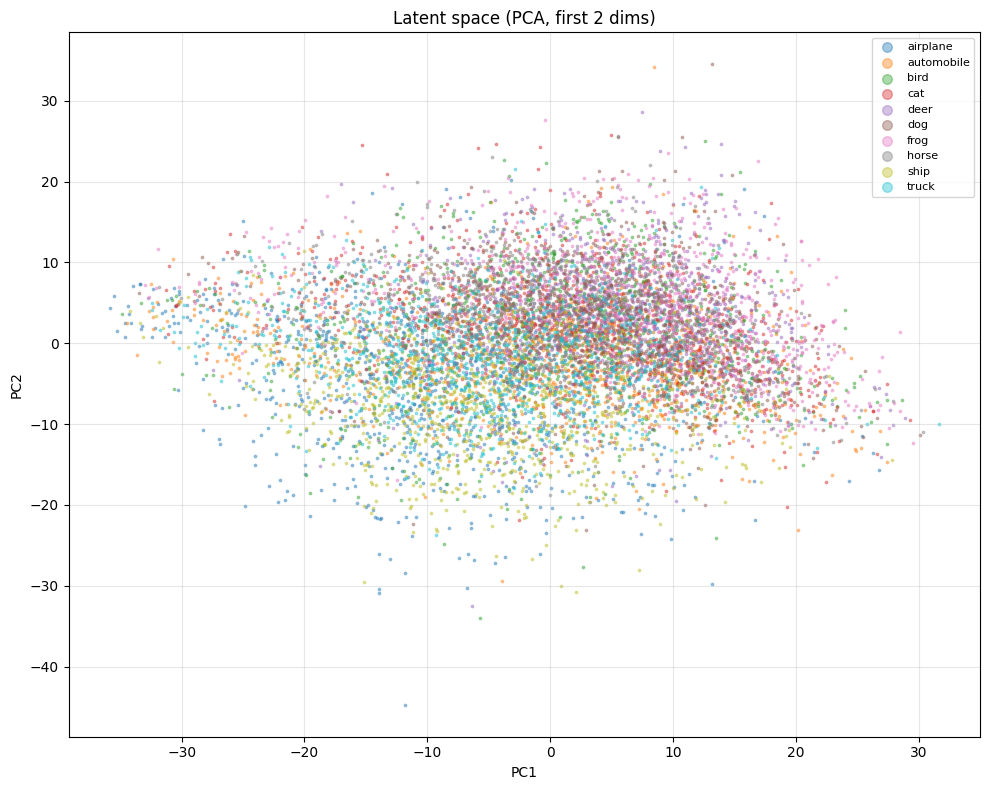

Model: "vae_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_L4 (Functional)         │ ((None, 4, 4, 64),     │       137,392 │
│                                 │ (None, 4, 4, 64),      │               │
│                                 │ (None, 4, 4, 64))      │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ input_layer_8 (InputLayer) │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ enc_conv_0 (Conv2D)        │ (None, 16, 16, 16)     │           432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ enc_bn_0                   │ (None, 16, 16, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ enc_relu_0 (Activation)    │ (None, 16, 16, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ enc_1x1_0 (Conv2D)         │ (None, 16, 16, 16)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ enc_bn1x1_0                │ (None, 16, 16, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ enc_relu1x1_0 (Activation) │ (None, 16, 16, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ enc_conv_1 (Conv2D)        │ (None, 8, 8, 32)       │         4,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ enc_bn_1                   │ (None, 8, 8, 32)       │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ enc_relu_1 (Activation)    │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ enc_1x1_1 (Conv2D)         │ (None, 8, 8, 32)       │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ enc_bn1x1_1                │ (None, 8, 8, 32)       │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ enc_relu1x1_1 (Activation) │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ enc_conv_2 (Conv2D)        │ (None, 4, 4, 64)       │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ enc_bn_2                   │ (None, 4, 4, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ enc_relu_2 (Activation)    │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ enc_1x1_2 (Conv2D)         │ (None, 4, 4, 64)       │         4,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ enc_bn1x1_2                │ (None, 4, 4, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ enc_relu1x1_2 (Activation) │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ enc_conv_3 (Conv2D)        │ (None, 4, 4, 128)      │        73,72

 Total params: 881,998 (3.36 MB)

 Trainable params: 263,731 (1.01 MB)

 Non-trainable params: 90,800 (354.69 KB)

 Optimizer params: 527,467 (2.01 MB)

In [ ]:
# Cell 6: Latent Space Visualisation
# PCA of the spatial latent space, coloured by class.
# A well-trained VAE should show smooth, overlapping blobs.

(_, y_test_labels) = keras.datasets.cifar10.load_data()[1]

z_means, _, _ = encoder.predict(x_test, verbose=0)

# Flatten spatial latent map to a vector per sample: (N, H, W, C) -> (N, H*W*C)
z_means_flat = z_means.reshape(z_means.shape[0], -1)

# Manual PCA using NumPy
z_centred            = z_means_flat - z_means_flat.mean(axis=0)
cov                  = np.cov(z_centred, rowvar=False)
eigenvals, eigenvecs = np.linalg.eigh(cov)
# eigh returns ascending order -- take the last 2 (largest variance)
top2 = eigenvecs[:, -2:][:, ::-1]
z_2d = z_centred @ top2

labels          = y_test_labels.flatten()
cifar10_classes = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']

plt.figure(figsize=(10, 8))
for cls in range(10):
    mask = labels == cls
    plt.scatter(z_2d[mask, 0], z_2d[mask, 1], s=3, alpha=0.4, label=cifar10_classes[cls])
plt.title('Latent space (PCA, first 2 dims)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(markerscale=4, loc='best', fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

vae.summary(expand_nested=True)